# Modelos Autorregressivos (AR) e de Médias Móveis (MA) em Séries Temporais

### Preparação: Importando Bibliotecas e Configurando Gráficos

In [1]:
import numpy as np # Para cálculos numéricos
import pandas as pd # Para trabalhar com dados em tabelas (DataFrames)
import matplotlib.pyplot as plt # Para criar gráficos
import seaborn as sns # Para gráficos mais bonitos e informativos
import statsmodels.api as sm # Pacote principal para modelos estatísticos e séries temporais
from statsmodels.tsa.stattools import adfuller, kpss # Testes de estacionariedade (ADF e KPSS)
from statsmodels.tsa.ar_model import AutoReg # Modelo Autorregressivo puro
from statsmodels.tsa.arima.model import ARIMA # Usado para modelos MA, ARMA, ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf # Para plotar FAC e FACP
from sklearn.metrics import mean_absolute_error, mean_squared_error # Métricas para avaliar modelos

# Configurações globais para melhorar a visualização dos gráficos
plt.rcParams['figure.figsize'] = (15, 6) # Define o tamanho padrão das figuras
plt.style.use('seaborn-v0_8-darkgrid') # Aplica um estilo estético do seaborn
sns.set_palette('deep') # Define uma paleta de cores padrão


## 1. Modelos Autorregressivos (AR)

Um **Processo Autorregressivo de ordem $p$ (AR($p$))** descreve uma série onde o valor atual ($X_t$) depende linearmente de seus *valores anteriores* ($X_{t-1}, X_{t-2}, \dots, X_{t-p}$), mais um erro aleatório.

### 1.1. A Equação de um AR($p$)

$$X_t = c + \phi_1 X_{t-1} + \phi_2 X_{t-2} + \dots + \phi_p X_{t-p} + \epsilon_t$$ 

Onde:
- $X_t$: O valor da série no tempo $t$.
- $c$: Uma constante (intercepto).
- $\phi_1, \dots, \phi_p$: Coeficientes que medem a influência de cada valor passado.
- $\epsilon_t$: O **termo de erro (ou ruído branco)**, que é aleatório, não correlacionado, com média zero e variância constante.

**Estacionariedade AR($p$)**: Para um AR($p$) ser estacionário (o que é crucial para a modelagem), a influência dos choques passados deve diminuir com o tempo. Isso é garantido por condições nos coeficientes $\phi$ (ex: para AR(1), $|\phi_1| < 1$).


### 1.2. Como Identificar a Ordem $p$ de um AR($p$) (FAC e FACP)

Para identificar a ordem $p$ de um modelo AR, olhamos os gráficos de Funções de Autocorrelação (FAC) e Autocorrelação Parcial (FACP):

-   **Função de Autocorrelação (FAC)**: Para um AR($p$), a FAC mostra um **decaimento gradual** (exponencial ou oscilatório) das autocorrelações à medida que o *lag* (atraso) aumenta. Não há um corte abrupto.
-   **Função de Autocorrelação Parcial (FACP)**: Para um AR($p$), a FACP exibe autocorrelações parciais **significativas apenas para os primeiros $p$ lags**. A partir do lag $p+1$, elas caem abruptamente para zero (dentro dos limites de significância). Este "**corte abrupto**" na FACP é a chave para identificar a ordem $p$ de um AR.


### 1.3. Exemplo Prático: Simulando um Processo AR(2)

Vamos simular um AR(2) com a equação:
$$X_t = 0.5 X_{t-1} + 0.4 X_{t-2} + \epsilon_t$$ 
Onde $\epsilon_t$ é ruído branco com média 0 e desvio padrão 3.

In [2]:
np.random.seed(123) # Define uma semente para garantir resultados repetíveis
n_obs = 200 # Número de observações na série
X_ar2 = np.zeros(n_obs) # Array para guardar os valores da série AR(2)
phi1 = 0.5 # Coeficiente para X_{t-1}
phi2 = 0.4 # Coeficiente para X_{t-2}
sigma_epsilon_ar2 = np.sqrt(9) # Desvio padrão do termo de erro

# Simulação do processo AR(2) passo a passo
for i in range(2, n_obs): # Começamos do índice 2 para ter X[i-1] e X[i-2]
    X_ar2[i] = phi1 * X_ar2[i-1] + phi2 * X_ar2[i-2] + np.random.normal(0, sigma_epsilon_ar2)


### 1.4. Visualizando e Interpretando o AR(2)

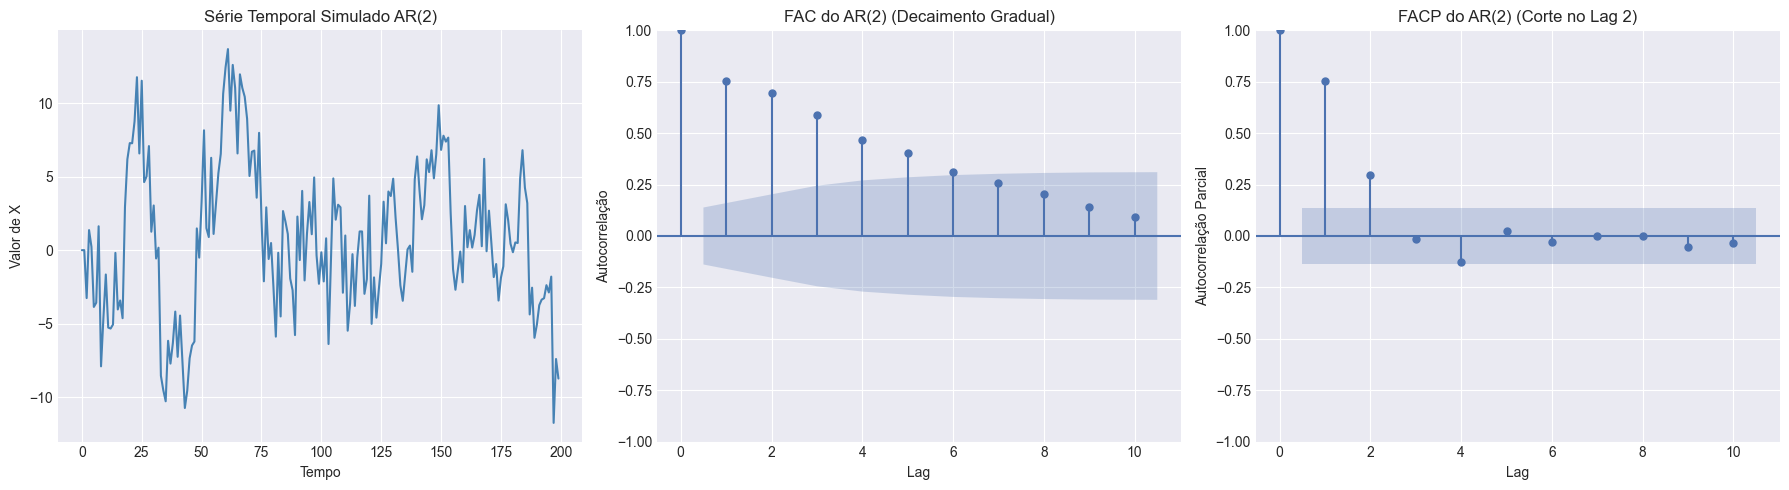

**Interpretação:**
- **Série Temporal**: Observamos flutuações em torno de uma média constante, típica de uma série estacionária.
- **FAC**: As barras decaem gradualmente, sem um corte abrupto. Isso é característico de um modelo AR.
- **FACP**: Vemos picos significativos nos lags 1 e 2. Depois, as barras caem drasticamente para dentro da área sombreada (não significativa). Isso indica um **corte no lag 2**, confirmando que a ordem do modelo AR é **p=2**.


In [3]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1) # Primeiro gráfico: a própria série
plt.plot(X_ar2, color='steelblue')
plt.title('Série Temporal Simulado AR(2)')
plt.xlabel('Tempo')
plt.ylabel('Valor de X')

plt.subplot(1, 3, 2) # Segundo gráfico: Função de Autocorrelação (FAC)
plot_acf(X_ar2, lags=10, ax=plt.gca(), title='FAC do AR(2) (Decaimento Gradual)')
plt.xlabel('Lag')
plt.ylabel('Autocorrelação')

plt.subplot(1, 3, 3) # Terceiro gráfico: Função de Autocorrelação Parcial (FACP)
plot_pacf(X_ar2, lags=10, ax=plt.gca(), title='FACP do AR(2) (Corte no Lag 2)')
plt.xlabel('Lag')
plt.ylabel('Autocorrelação Parcial')

plt.tight_layout() # Ajusta o espaçamento entre os gráficos
plt.show()

print("**Interpretação:**")
print("- **Série Temporal**: Observamos flutuações em torno de uma média constante, típica de uma série estacionária.")
print("- **FAC**: As barras decaem gradualmente, sem um corte abrupto. Isso é característico de um modelo AR.")
print("- **FACP**: Vemos picos significativos nos lags 1 e 2. Depois, as barras caem drasticamente para dentro da área sombreada (não significativa). Isso indica um **corte no lag 2**, confirmando que a ordem do modelo AR é **p=2**.")


### 1.5. Exemplo Adicional: Simulando um Processo AR(3)

Vamos ver como se parece um AR(3):
$$X_t = 0.3 X_{t-1} + 0.4 X_{t-2} + 0.2 X_{t-3} + \epsilon_t$$ 
Onde $\epsilon_t$ é ruído branco com média 0 e desvio padrão $\sqrt{3}$.

In [4]:
np.random.seed(456) # Nova semente para este exemplo
n_obs = 200
X_ar3 = np.zeros(n_obs)
phi1_ar3 = 0.3
phi2_ar3 = 0.4
phi3_ar3 = 0.2
sigma_epsilon_ar3 = np.sqrt(3)

# Simulação do processo AR(3)
for i in range(3, n_obs):
    X_ar3[i] = phi1_ar3 * X_ar3[i-1] + phi2_ar3 * X_ar3[i-2] + phi3_ar3 * X_ar3[i-3] + np.random.normal(0, sigma_epsilon_ar3)


### 1.6. Visualizando e Interpretando o AR(3)

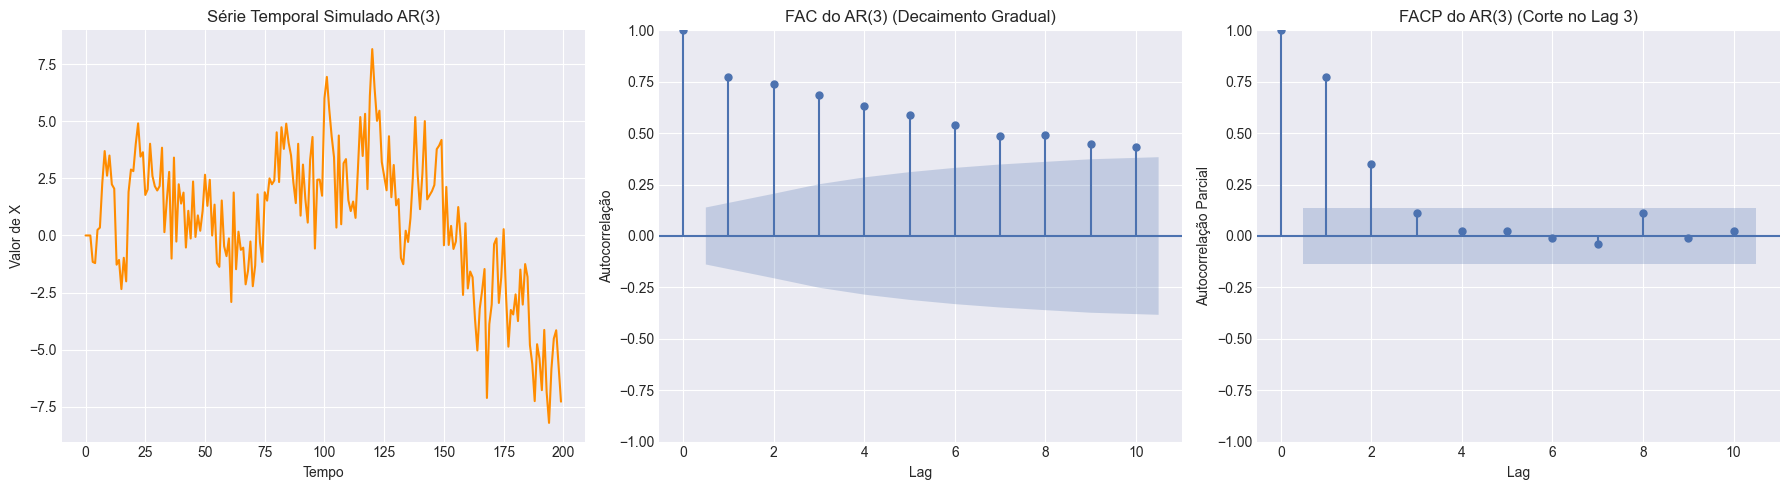

**Interpretação:**
- **FAC**: Novamente, um decaimento gradual.
- **FACP**: O corte significativo agora ocorre após o **lag 3**, o que confirma a ordem **p=3** para este AR.


In [5]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(X_ar3, color='darkorange')
plt.title('Série Temporal Simulado AR(3)')
plt.xlabel('Tempo')
plt.ylabel('Valor de X')

plt.subplot(1, 3, 2)
plot_acf(X_ar3, lags=10, ax=plt.gca(), title='FAC do AR(3) (Decaimento Gradual)')
plt.xlabel('Lag')
plt.ylabel('Autocorrelação')

plt.subplot(1, 3, 3)
plot_pacf(X_ar3, lags=10, ax=plt.gca(), title='FACP do AR(3) (Corte no Lag 3)')
plt.xlabel('Lag')
plt.ylabel('Autocorrelação Parcial')

plt.tight_layout()
plt.show()

print("**Interpretação:**")
print("- **FAC**: Novamente, um decaimento gradual.")
print("- **FACP**: O corte significativo agora ocorre após o **lag 3**, o que confirma a ordem **p=3** para este AR.")


## 2. Modelos de Médias Móveis (MA)

Um **Processo de Médias Móveis de ordem $q$ (MA($q$))** modela o valor atual de uma série ($X_t$) como uma combinação linear dos $q$ *termos de erro passados*, mais o termo de erro atual.

### 2.1. A Equação de um MA($q$)

$$X_t = \mu + \epsilon_t + \theta_1 \epsilon_{t-1} + \theta_2 \epsilon_{t-2} + \dots + \theta_q \epsilon_{t-q}$$ 

Onde:
- $X_t$: O valor da série no tempo $t$.
- $\mu$: A média da série.
- $\epsilon_t$: O termo de **ruído branco** (o erro no tempo $t$).
- $\theta_1, \dots, \theta_q$: Coeficientes que medem a influência de cada erro passado.

**Estacionariedade MA($q$)**: Uma vantagem dos processos MA($q$) é que eles **são sempre estacionários** por definição, desde que o ruído branco também seja. Isso porque a dependência dos erros passados é limitada a $q$ períodos.


### 2.2. Como Identificar a Ordem $q$ de um MA($q$) (FAC e FACP)

Para identificar a ordem $q$ de um modelo MA, observamos os gráficos de FAC e FACP de forma oposta ao AR:

-   **Função de Autocorrelação (FAC)**: Para um MA($q$), a FAC exibe autocorrelações **significativas apenas para os primeiros $q$ lags**. A partir do lag $q+1$, elas caem abruptamente para zero. Este "**corte abrupto**" na FAC é a chave para identificar a ordem $q$ de um MA.
-   **Função de Autocorrelação Parcial (FACP)**: Para um MA($q$), a FACP mostra um **decaimento gradual** (exponencial ou oscilatório) das autocorrelações parciais à medida que o *lag* aumenta. Não há um corte abrupto.


### 2.3. Exemplo Prático: Simulando um Processo MA(1) (Coeficiente Positivo)

Vamos simular um MA(1) com um coeficiente positivo:

$$X_t = \epsilon_t + 0.7 \epsilon_{t-1}$$ 
Onde $\epsilon_t$ é ruído branco com média 0 e desvio padrão 3.

In [6]:
np.random.seed(789) # Semente para reprodutibilidade
n_obs = 200
errors_ma1_pos = np.random.normal(0, np.sqrt(9), n_obs) # Gerando os termos de erro
X_ma1_pos = np.zeros(n_obs)
theta1_ma1_pos = 0.7 # Coeficiente MA para o lag 1

# Simulação do processo MA(1)
for i in range(1, n_obs):
    X_ma1_pos[i] = errors_ma1_pos[i] + theta1_ma1_pos * errors_ma1_pos[i-1]


### 2.4. Visualizando e Interpretando o MA(1) (Coeficiente Positivo)

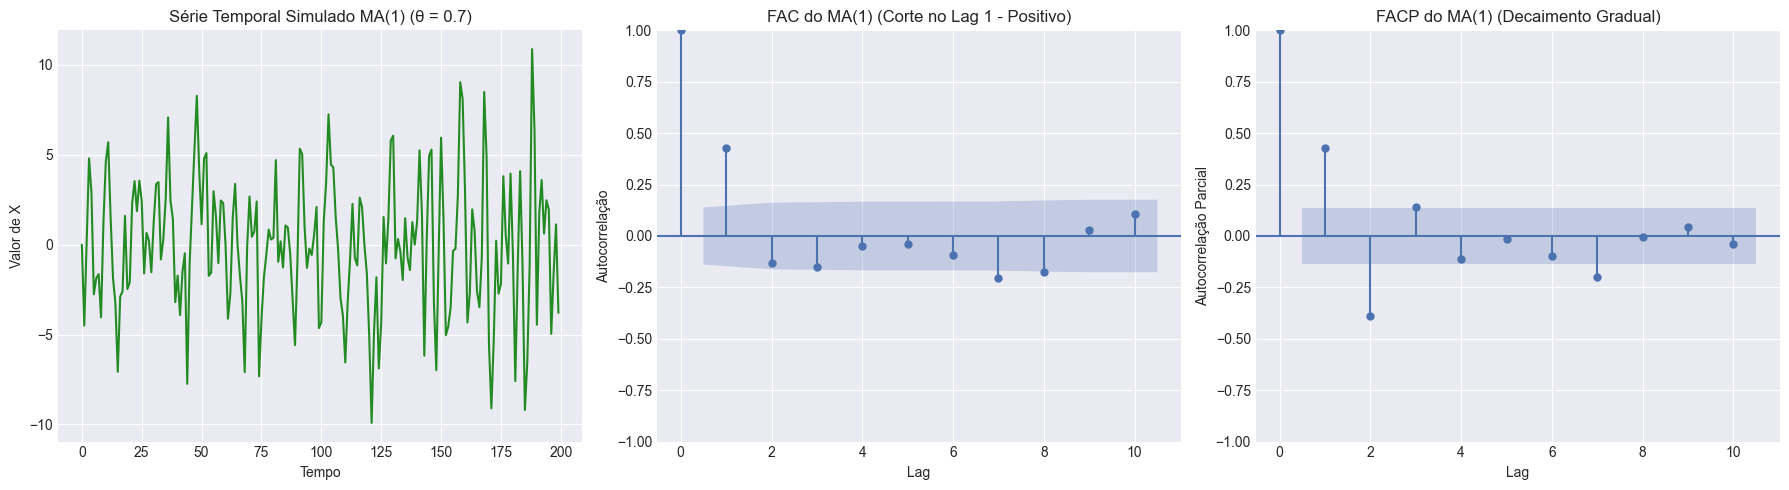

**Interpretação:**
- **Série Temporal**: Comportamento estacionário.
- **FAC**: Há um pico significativo apenas no **lag 1** (positivo), e depois um **corte abrupto**. Isso é a característica principal de um MA(1).
- **FACP**: As barras decaem gradualmente, sem um corte claro. Isso é o esperado para um MA.


In [7]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(X_ma1_pos, color='forestgreen')
plt.title('Série Temporal Simulado MA(1) (θ = 0.7)')
plt.xlabel('Tempo')
plt.ylabel('Valor de X')

plt.subplot(1, 3, 2)
plot_acf(X_ma1_pos, lags=10, ax=plt.gca(), title='FAC do MA(1) (Corte no Lag 1 - Positivo)')
plt.xlabel('Lag')
plt.ylabel('Autocorrelação')

plt.subplot(1, 3, 3)
plot_pacf(X_ma1_pos, lags=10, ax=plt.gca(), title='FACP do MA(1) (Decaimento Gradual)')
plt.xlabel('Lag')
plt.ylabel('Autocorrelação Parcial')

plt.tight_layout()
plt.show()

print("**Interpretação:**")
print("- **Série Temporal**: Comportamento estacionário.")
print("- **FAC**: Há um pico significativo apenas no **lag 1** (positivo), e depois um **corte abrupto**. Isso é a característica principal de um MA(1).")
print("- **FACP**: As barras decaem gradualmente, sem um corte claro. Isso é o esperado para um MA.")


### 2.5. Exemplo: Simulação de um Processo MA(1) (Coeficiente Negativo)

Agora, um MA(1) com um coeficiente negativo para ver a diferença no gráfico FAC:

$$X_t = \epsilon_t - 0.7 \epsilon_{t-1}$$ 
Onde $\epsilon_t$ é ruído branco com média 0 e desvio padrão 3.

In [8]:
np.random.seed(1011) # Nova semente
n_obs = 200
errors_ma1_neg = np.random.normal(0, np.sqrt(9), n_obs)
X_ma1_neg = np.zeros(n_obs)
theta1_ma1_neg = -0.7 # Coeficiente MA negativo

# Simulação do processo MA(1) com coeficiente negativo
for i in range(1, n_obs):
    X_ma1_neg[i] = errors_ma1_neg[i] + theta1_ma1_neg * errors_ma1_neg[i-1]


### 2.6. Visualizando e Interpretando o MA(1) (Coeficiente Negativo)

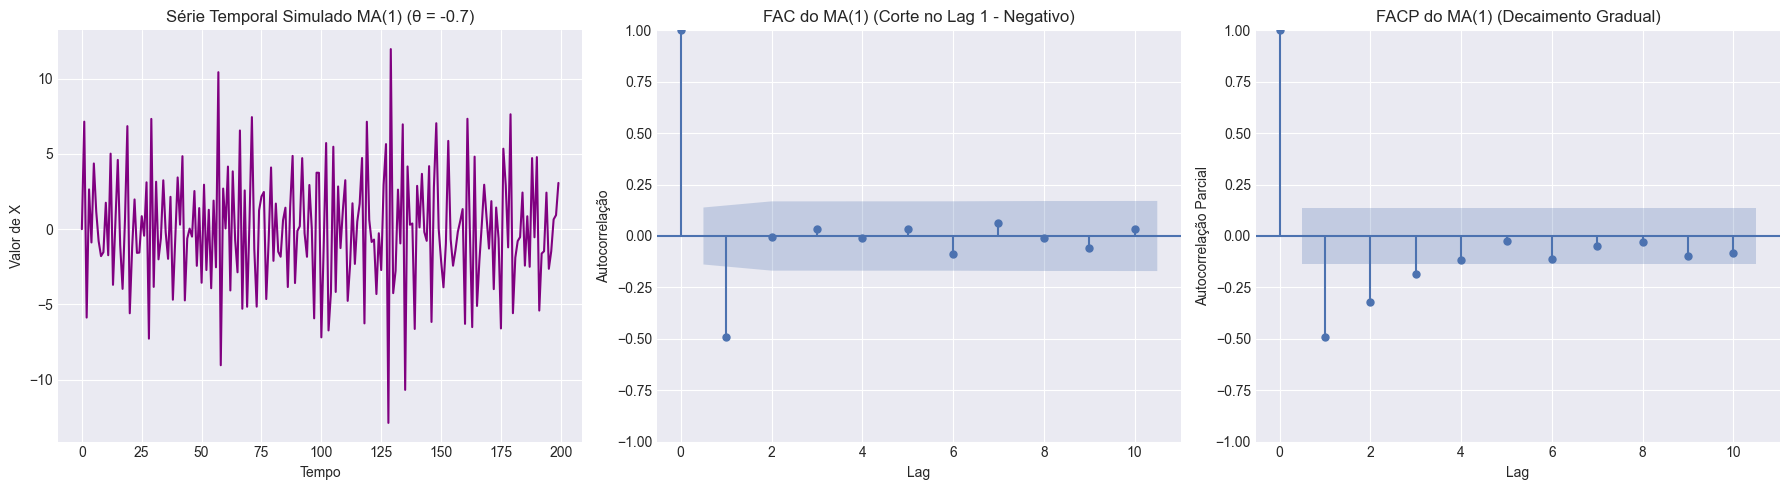

**Interpretação:**
- **FAC**: O pico significativo ainda está no **lag 1**, mas agora é **negativo**, refletindo o coeficiente negativo. O corte abrupto ainda acontece no lag 1.
- **FACP**: Continua a mostrar um decaimento gradual.


In [9]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(X_ma1_neg, color='purple')
plt.title('Série Temporal Simulado MA(1) (θ = -0.7)')
plt.xlabel('Tempo')
plt.ylabel('Valor de X')

plt.subplot(1, 3, 2)
plot_acf(X_ma1_neg, lags=10, ax=plt.gca(), title='FAC do MA(1) (Corte no Lag 1 - Negativo)')
plt.xlabel('Lag')
plt.ylabel('Autocorrelação')

plt.subplot(1, 3, 3)
plot_pacf(X_ma1_neg, lags=10, ax=plt.gca(), title='FACP do MA(1) (Decaimento Gradual)')
plt.xlabel('Lag')
plt.ylabel('Autocorrelação Parcial')

plt.tight_layout()
plt.show()

print("**Interpretação:**")
print("- **FAC**: O pico significativo ainda está no **lag 1**, mas agora é **negativo**, refletindo o coeficiente negativo. O corte abrupto ainda acontece no lag 1.")
print("- **FACP**: Continua a mostrar um decaimento gradual.")


### 2.7. Exemplo Adicional: Simulando um Processo MA(2)

Para finalizar os exemplos de MA, vamos simular um processo MA(2):

$$X_t = \epsilon_t + 0.5 \epsilon_{t-1} - 0.4 \epsilon_{t-2}$$ 
Onde $\epsilon_t$ é ruído branco com média 0 e desvio padrão 3.

In [ ]:
np.random.seed(1234) # Nova semente
n_obs = 200
errors_ma2 = np.random.normal(0, np.sqrt(9), n_obs)
X_ma2 = np.zeros(n_obs)
theta1_ma2 = 0.5
theta2_ma2 = -0.4

# Simulação do processo MA(2)
for i in range(2, n_obs):
    X_ma2[i] = errors_ma2[i] + theta1_ma2 * errors_ma2[i-1] + theta2_ma2 * errors_ma2[i-2]


### 2.8. Visualizando e Interpretando o MA(2)

In [ ]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(X_ma2, color='firebrick')
plt.title('Série Temporal Simulado MA(2)')
plt.xlabel('Tempo')
plt.ylabel('Valor de X')

plt.subplot(1, 3, 2)
plot_acf(X_ma2, lags=10, ax=plt.gca(), title='FAC do MA(2) (Corte no Lag 2)')
plt.xlabel('Lag')
plt.ylabel('Autocorrelação')

plt.subplot(1, 3, 3)
plot_pacf(X_ma2, lags=10, ax=plt.gca(), title='FACP do MA(2) (Decaimento Gradual)')
plt.xlabel('Lag')
plt.ylabel('Autocorrelação Parcial')

plt.tight_layout()
plt.show()

print("**Interpretação:**")
print("- **FAC**: As autocorrelações são significativas nos **lags 1 e 2**, e depois há um **corte abrupto**. Isso é o que esperamos de um MA(2).")
print("- **FACP**: As autocorrelações parciais decaem gradualmente, confirmando a natureza de MA.")


## 3. Resumo da Identificação de Modelos AR e MA (FAC e FACP)

Este quadro resume como identificar a ordem de modelos AR e MA usando os gráficos de Autocorrelação:

| Modelo        | Comportamento da FAC       | Comportamento da FACP    | Qual gráfico usar para identificar a ordem? |
| :------------ | :------------------------- | :----------------------- | :------------------------------------------ |
| **AR($p$)** | Decaimento gradual         | **Corte abrupto** após $p$ lags | **FACP (para ordem $p$)** |
| **MA($q$)** | **Corte abrupto** após $q$ lags | Decaimento gradual       | **FAC (para ordem $q$)** |

Essa diferença é fundamental para escolher o modelo certo para sua série temporal.

## 4. Estacionariedade de Séries Temporais (Testes ADF e KPSS)

Antes de aplicar modelos AR ou MA (ou ARMA/ARIMA), é crucial que a série temporal seja **estacionária**. Uma série estacionária tem média, variância e autocorrelação constantes ao longo do tempo. Se a série não for estacionária, geralmente precisamos diferenciá-la.

Vamos entender os testes de estacionariedade mais comuns:

### 4.1. Teste ADF (Augmented Dickey-Fuller)

-   **Hipótese Nula (H0)**: A série *NÃO* é estacionária (possui uma raiz unitária).
-   **Hipótese Alternativa (Ha)**: A série é estacionária.
-   **Interpretação**: Se o **p-valor for MENOR ou igual ao nível de significância** (ex: 0.05), **rejeitamos H0**, indicando que a série **É estacionária**.

### 4.2. Teste KPSS (Kwiatkowski-Phillips-Schmidt-Shin)

-   **Hipótese Nula (H0)**: A série É estacionária (em torno da média ou tendência).
-   **Hipótese Alternativa (Ha)**: A série NÃO é estacionária.
-   **Interpretação**: Se o **p-valor for MENOR ou igual ao nível de significância** (ex: 0.05), **rejeitamos H0**, indicando que a série **NÃO é estacionária**.

Ambos os testes são complementares. Para confirmar a estacionariedade, idealmente o ADF deve rejeitar H0 (p-valor baixo) e o KPSS deve *falhar em rejeitar* H0 (p-valor alto).